In [1]:
# 0단계: 런타임 확인

!nvidia-smi

Thu Jul  9 00:45:41 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   55C    P8             12W /   70W |       0MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [2]:
# 1단계: 패키지 설치

!pip install ultralytics -q

In [3]:
# 2단계: 모델 불러오기 (구글 드라이브에서)

from google.colab import drive

drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [4]:
# 2단계: 모델 불러오기 (구글 드라이브에서)

from ultralytics import YOLO

model = YOLO("/content/drive/MyDrive/chess_yolo_models/chess_final_side1_best.pt")

print("모델 로드 완료")

모델 로드 완료


In [8]:
# 3단계: 빈 체스판 이미지 업로드

from google.colab import files
import shutil

uploaded = files.upload()  # 빈 체스판 사진 선택

original_filename = list(uploaded.keys())[0]
shutil.move(original_filename, "/content/empty_board.jpg")
img_path = "/content/empty_board.jpg"

print("저장 완료:", img_path)

# from google.colab import files
# import shutil

# uploaded = files.upload()

# if uploaded:
#     original_filename = next(iter(uploaded))
#     shutil.move(original_filename, "/content/empty_board.jpg")
#     print("저장 완료: /content/empty_board.jpg")
# else:
#     print("업로드된 파일이 없습니다.")

Saving 빈 체스판1.jpg to 빈 체스판1.jpg
저장 완료: /content/empty_board.jpg


In [9]:
# 4단계: 테스트할 새 사진들 업로드 (여러 장 한번에 가능)

import os

new_test_dir = "/content/my_new_photos_2"
os.makedirs(new_test_dir, exist_ok=True)

uploaded2 = files.upload()  # 테스트할 사진들 선택 (여러 장 동시 선택 가능)

for filename in uploaded2.keys():
    shutil.move(filename, f"{new_test_dir}/{filename}")

print("업로드 완료:", os.listdir(new_test_dir))

Saving 22222.jpg to 22222.jpg
업로드 완료: ['22222.jpg']


In [10]:
# 5단계: 원근 변환 행렬 재설정 (확정했던 좌표 그대로)

import cv2
import numpy as np

corners = {
    "h8": (196, 116),
    "h1": (452, 125),
    "a1": (507, 324),
    "a8": (166, 318),
}

src_pts = np.array([
    corners["h8"],
    corners["h1"],
    corners["a1"],
    corners["a8"],
], dtype=np.float32)

board_size = 800
dst_pts = np.array([
    [0, 0],
    [board_size, 0],
    [board_size, board_size],
    [0, board_size]
], dtype=np.float32)

TRANSFORM_MATRIX = cv2.getPerspectiveTransform(src_pts, dst_pts)
print("원근 변환 행렬 재설정 완료")

원근 변환 행렬 재설정 완료


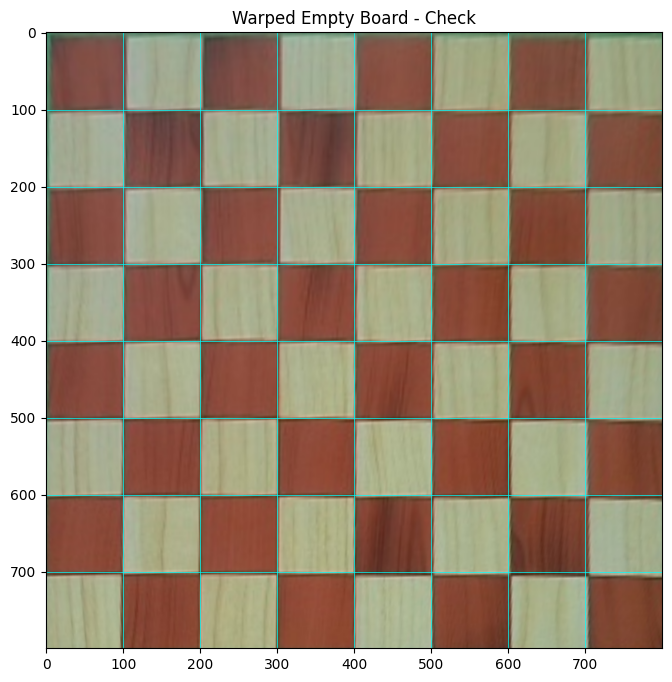

In [11]:
# 6단계: 검증 (변환이 잘 되는지 확인)

import matplotlib.pyplot as plt

img_cv = cv2.imread(img_path)
warped = cv2.warpPerspective(img_cv, TRANSFORM_MATRIX, (board_size, board_size))
warped_rgb = cv2.cvtColor(warped, cv2.COLOR_BGR2RGB)

plt.figure(figsize=(8, 8))
plt.imshow(warped_rgb)
plt.title("Warped Empty Board - Check")
for i in range(1, 8):
    plt.axhline(y=i*(board_size/8), color='cyan', linewidth=0.5)
    plt.axvline(x=i*(board_size/8), color='cyan', linewidth=0.5)
plt.show()

In [12]:
# 7단계: 칸 계산 함수 (좌표 뒤바뀜 수정 + 보드 밖 필터링 반영된 최종 버전)

def get_chess_square(x1, y1, x2, y2, matrix, board_size=800, margin=20):
    foot_x = (x1 + x2) / 2
    foot_y = y2

    point = np.array([[[foot_x, foot_y]]], dtype=np.float32)
    transformed = cv2.perspectiveTransform(point, matrix)
    tx, ty = transformed[0][0]

    if tx < -margin or tx > board_size + margin or ty < -margin or ty > board_size + margin:
        return None

    tx = max(0, min(board_size - 1, tx))
    ty = max(0, min(board_size - 1, ty))

    rank_index = int(tx / (board_size / 8))
    file_index = int(ty / (board_size / 8))

    rank_index = max(0, min(7, rank_index))
    file_index = max(0, min(7, file_index))

    rank_number = 8 - rank_index
    file_letter = "hgfedcba"[file_index]

    return f"{file_letter}{rank_number}"


image 1/1 /content/my_new_photos_2/22222.jpg: 480x640 2 black_bishops, 1 black_king, 2 black_knights, 8 black_pawns, 1 black_queen, 2 black_rooks, 2 white_bishops, 3 white_knights, 12 white_pawns, 1 white_queen, 1 white_rook, 79.6ms
Speed: 2.8ms preprocess, 79.6ms inference, 35.3ms postprocess per image at shape (1, 3, 480, 640)
체스판 안 기물: 8개 / 전체 검출: 35개


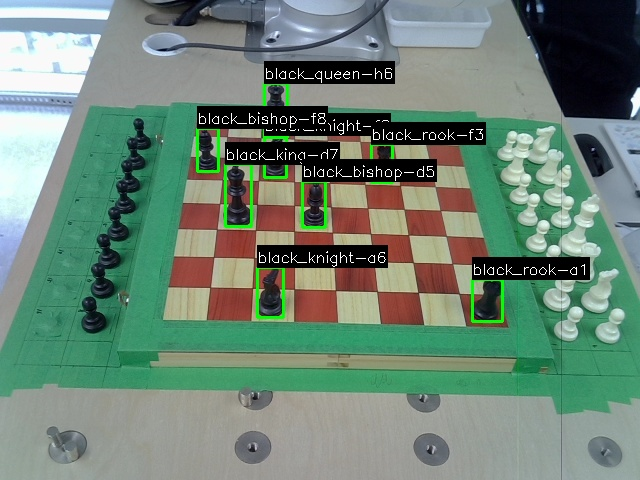

In [13]:
# 8단계: 실제 테스트 (예측 + 칸 계산 + 시각화)

from IPython.display import Image, display

test_img_path = f"{new_test_dir}/22222.jpg"  # 원하는 파일명으로 교체

results = model.predict(source=test_img_path, conf=0.25)
r = results[0]

valid_detections = []
for box in r.boxes:
    x1, y1, x2, y2 = box.xyxy[0].tolist()
    cls_id = int(box.cls[0])
    cls_name = model.names[cls_id]

    square = get_chess_square(x1, y1, x2, y2, TRANSFORM_MATRIX)
    if square is None:
        continue
    valid_detections.append((cls_name, square, (x1, y1, x2, y2)))

print(f"체스판 안 기물: {len(valid_detections)}개 / 전체 검출: {len(r.boxes)}개")

img_for_draw = cv2.imread(test_img_path)
box_color = (0, 255, 0)
text_color = (255, 255, 255)
bg_color = (0, 0, 0)
font = cv2.FONT_HERSHEY_SIMPLEX
font_scale = 0.5
thickness = 1

for cls_name, square, (x1, y1, x2, y2) in valid_detections:
    x1, y1, x2, y2 = map(int, (x1, y1, x2, y2))
    label = f"{cls_name}-{square}"
    cv2.rectangle(img_for_draw, (x1, y1), (x2, y2), box_color, 2)
    (text_w, text_h), baseline = cv2.getTextSize(label, font, font_scale, thickness)
    text_x, text_y = x1, max(y1 - 5, text_h + 5)
    cv2.rectangle(img_for_draw, (text_x, text_y - text_h - baseline),
                  (text_x + text_w, text_y + baseline), bg_color, -1)
    cv2.putText(img_for_draw, label, (text_x, text_y), font, font_scale, text_color, thickness)

save_path = "/content/square_check_final.jpg"
cv2.imwrite(save_path, img_for_draw)
display(Image(filename=save_path))

In [14]:
import os
print(os.listdir("/content/my_new_photos_2"))

['22222.jpg']



image 1/1 /content/my_new_photos_2/20260708_125319_074.jpg: 480x640 3 black_bishops, 1 black_king, 2 black_knights, 8 black_pawns, 2 black_queens, 2 black_rooks, 2 white_bishops, 1 white_king, 2 white_knights, 11 white_pawns, 1 white_queen, 2 white_rooks, 15.5ms
Speed: 2.6ms preprocess, 15.5ms inference, 1.8ms postprocess per image at shape (1, 3, 480, 640)

=== 20260708_125319_074.jpg ===
체스판 안 기물: 24개 / 전체 검출: 37개


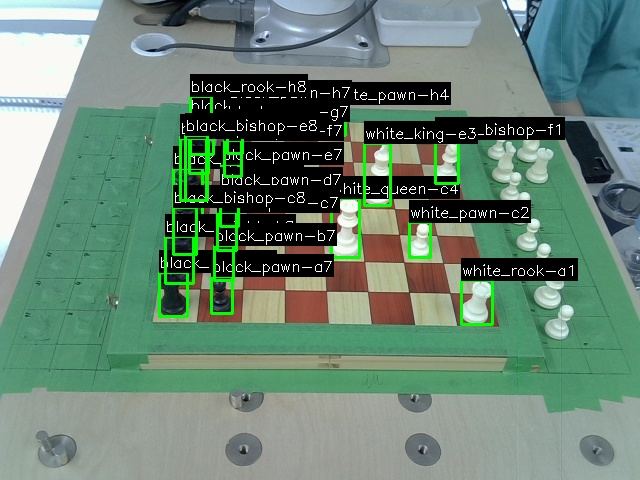


image 1/1 /content/my_new_photos_2/20260708_140504_969.jpg: 480x640 2 black_bishops, 1 black_king, 3 black_knights, 8 black_pawns, 2 black_queens, 2 black_rooks, 1 white_bishop, 1 white_king, 2 white_knights, 11 white_pawns, 1 white_queen, 2 white_rooks, 15.2ms
Speed: 1.5ms preprocess, 15.2ms inference, 1.5ms postprocess per image at shape (1, 3, 480, 640)

=== 20260708_140504_969.jpg ===
체스판 안 기물: 14개 / 전체 검출: 36개


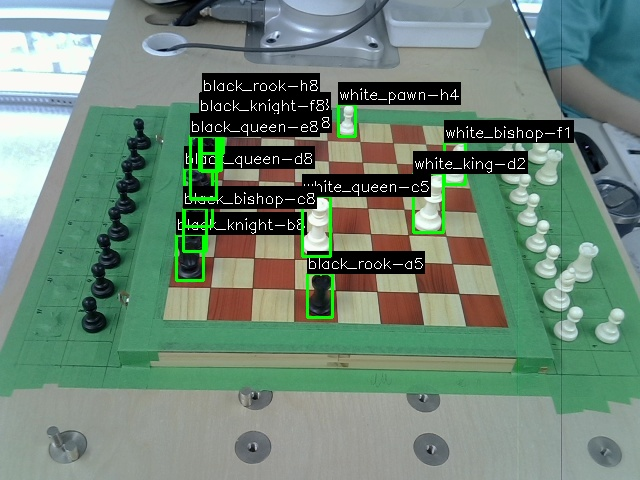


image 1/1 /content/my_new_photos_2/20260708_140531_712.jpg: 480x640 3 black_bishops, 2 black_knights, 12 black_pawns, 1 black_queen, 1 black_rook, 1 white_bishop, 1 white_king, 1 white_knight, 11 white_pawns, 1 white_queen, 2 white_rooks, 12.9ms
Speed: 1.6ms preprocess, 12.9ms inference, 1.7ms postprocess per image at shape (1, 3, 480, 640)

=== 20260708_140531_712.jpg ===
체스판 안 기물: 15개 / 전체 검출: 36개


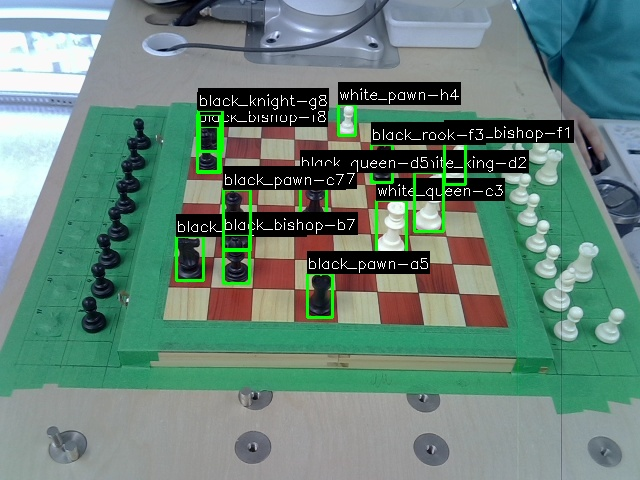


image 1/1 /content/my_new_photos_2/20260708_140534_817.jpg: 480x640 3 black_bishops, 2 black_knights, 12 black_pawns, 1 black_queen, 1 black_rook, 1 white_bishop, 1 white_king, 1 white_knight, 10 white_pawns, 1 white_queen, 2 white_rooks, 12.3ms
Speed: 1.6ms preprocess, 12.3ms inference, 1.8ms postprocess per image at shape (1, 3, 480, 640)

=== 20260708_140534_817.jpg ===
체스판 안 기물: 15개 / 전체 검출: 35개


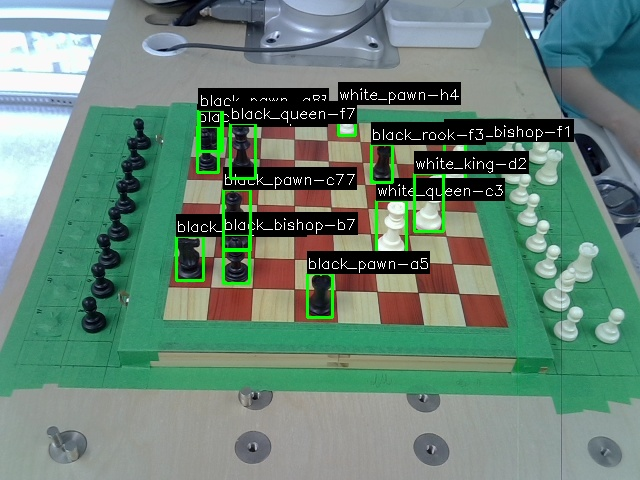


image 1/1 /content/my_new_photos_2/20260708_140555_592.jpg: 480x640 2 black_bishops, 1 black_king, 2 black_knights, 8 black_pawns, 1 black_queen, 2 black_rooks, 2 white_bishops, 1 white_king, 1 white_knight, 11 white_pawns, 1 white_queen, 2 white_rooks, 13.0ms
Speed: 2.9ms preprocess, 13.0ms inference, 1.9ms postprocess per image at shape (1, 3, 480, 640)

=== 20260708_140555_592.jpg ===
체스판 안 기물: 12개 / 전체 검출: 34개


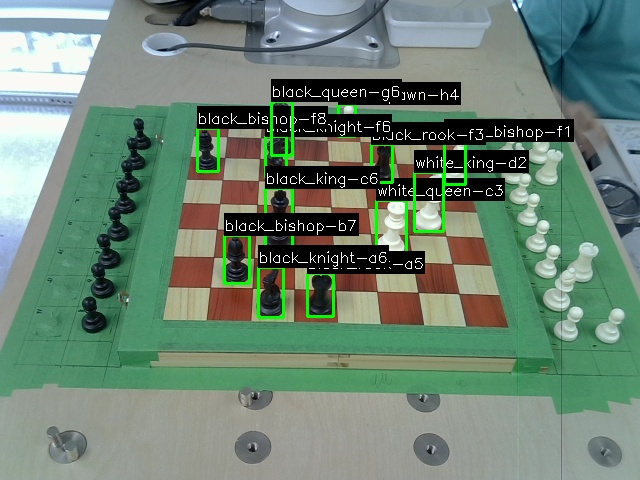

In [16]:
import os
import cv2
from IPython.display import Image, display

# 테스트할 이미지 목록 (원하는 파일명들로 직접 지정하거나, 폴더 전체를 쓰려면 아래 주석 참고)
test_images = [
    "20260708_125319_074.jpg",
    "20260708_140504_969.jpg",
    "20260708_140531_712.jpg",
    "20260708_140534_817.jpg",
    "20260708_140555_592.jpg"
    # 원하는 파일명 추가
]

# 또는 폴더 안 전체 이미지를 다 테스트하고 싶다면:
# test_images = os.listdir(new_test_dir)

box_color = (0, 255, 0)
text_color = (255, 255, 255)
bg_color = (0, 0, 0)
font = cv2.FONT_HERSHEY_SIMPLEX
font_scale = 0.5
thickness = 1

for fname in test_images:
    test_img_path = f"{new_test_dir}/{fname}"

    if not os.path.exists(test_img_path):
        print(f"파일 없음, 건너뜀: {test_img_path}")
        continue

    results = model.predict(source=test_img_path, conf=0.25)
    r = results[0]

    valid_detections = []
    for box in r.boxes:
        x1, y1, x2, y2 = box.xyxy[0].tolist()
        cls_id = int(box.cls[0])
        cls_name = model.names[cls_id]

        square = get_chess_square(x1, y1, x2, y2, TRANSFORM_MATRIX)
        if square is None:
            continue
        valid_detections.append((cls_name, square, (x1, y1, x2, y2)))

    print(f"\n=== {fname} ===")
    print(f"체스판 안 기물: {len(valid_detections)}개 / 전체 검출: {len(r.boxes)}개")

    img_for_draw = cv2.imread(test_img_path)

    for cls_name, square, (x1, y1, x2, y2) in valid_detections:
        x1, y1, x2, y2 = map(int, (x1, y1, x2, y2))
        label = f"{cls_name}-{square}"
        cv2.rectangle(img_for_draw, (x1, y1), (x2, y2), box_color, 2)
        (text_w, text_h), baseline = cv2.getTextSize(label, font, font_scale, thickness)
        text_x, text_y = x1, max(y1 - 5, text_h + 5)
        cv2.rectangle(img_for_draw, (text_x, text_y - text_h - baseline),
                      (text_x + text_w, text_y + baseline), bg_color, -1)
        cv2.putText(img_for_draw, label, (text_x, text_y), font, font_scale, text_color, thickness)

    save_path = f"/content/square_check_{fname}"
    cv2.imwrite(save_path, img_for_draw)
    display(Image(filename=save_path))

In [15]:
print(new_test_dir)

/content/my_new_photos_2


객체 검출 + 좌표 인식

In [16]:
results = model.predict(source=test_img_path, conf=0.25)
r = results[0]

valid_detections = []
for box in r.boxes:
    x1, y1, x2, y2 = box.xyxy[0].tolist()
    cls_id = int(box.cls[0])
    cls_name = model.names[cls_id]
    conf = float(box.conf[0])

    square = get_chess_square(x1, y1, x2, y2, TRANSFORM_MATRIX)
    if square is None:
        continue

    center_x = int((x1 + x2) / 2)
    center_y = int((y1 + y2) / 2)

    valid_detections.append({
        "class": cls_name,
        "conf": conf,
        "square": square,
        "center": (center_x, center_y),
        "bbox": (x1, y1, x2, y2)
    })


image 1/1 /content/my_new_photos_2/22222.jpg: 480x640 2 black_bishops, 1 black_king, 2 black_knights, 8 black_pawns, 1 black_queen, 2 black_rooks, 2 white_bishops, 3 white_knights, 12 white_pawns, 1 white_queen, 1 white_rook, 12.5ms
Speed: 2.3ms preprocess, 12.5ms inference, 1.7ms postprocess per image at shape (1, 3, 480, 640)


In [17]:
print(f"체스판 안 기물: {len(valid_detections)}개\n")

for d in valid_detections:
    print(f"{d['class']} | conf: {d['conf']:.2f} | square: {d['square']} | center: {d['center']}")

체스판 안 기물: 8개

black_queen | conf: 0.90 | square: h6 | center: (276, 110)
black_knight | conf: 0.90 | square: f6 | center: (275, 156)
black_rook | conf: 0.89 | square: f3 | center: (381, 163)
black_king | conf: 0.88 | square: d7 | center: (238, 195)
black_bishop | conf: 0.88 | square: d5 | center: (314, 204)
black_bishop | conf: 0.86 | square: f8 | center: (207, 149)
black_rook | conf: 0.82 | square: a1 | center: (487, 300)
black_knight | conf: 0.79 | square: a6 | center: (270, 292)


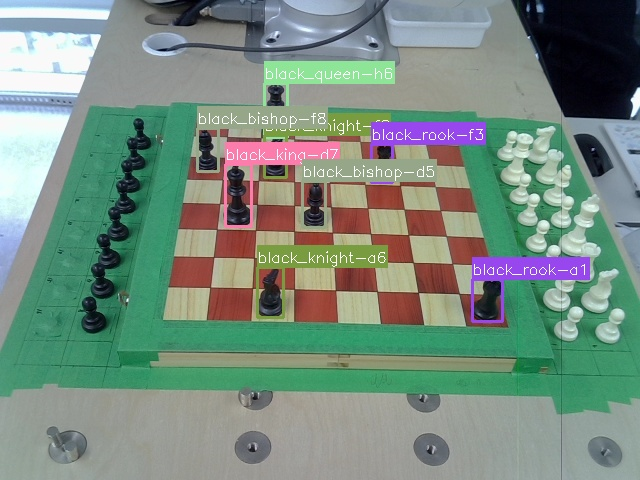

체스판 안 기물: 8개

black_queen | conf: 0.90 | square: h6 | center: (276, 110)
black_knight | conf: 0.90 | square: f6 | center: (275, 156)
black_rook | conf: 0.89 | square: f3 | center: (381, 163)
black_king | conf: 0.88 | square: d7 | center: (238, 195)
black_bishop | conf: 0.88 | square: d5 | center: (314, 204)
black_bishop | conf: 0.86 | square: f8 | center: (207, 149)
black_rook | conf: 0.82 | square: a1 | center: (487, 300)
black_knight | conf: 0.79 | square: a6 | center: (270, 292)


In [20]:
import cv2
import numpy as np
from IPython.display import Image, display

img_for_draw = cv2.imread(test_img_path)

np.random.seed(42)
class_colors = {}

def get_color(cls_name):
    if cls_name not in class_colors:
        class_colors[cls_name] = tuple(int(c) for c in np.random.randint(50, 255, size=3))
    return class_colors[cls_name]

font = cv2.FONT_HERSHEY_SIMPLEX
font_scale = 0.5
thickness = 1

for d in valid_detections:
    x1, y1, x2, y2 = map(int, d["bbox"])
    color = get_color(d["class"])
    label = f"{d['class']}-{d['square']}"   # 확신도 제외, 클래스-칸만

    cv2.rectangle(img_for_draw, (x1, y1), (x2, y2), color, 2)

    (text_w, text_h), baseline = cv2.getTextSize(label, font, font_scale, thickness)
    text_x, text_y = x1, max(y1 - 5, text_h + 5)

    cv2.rectangle(img_for_draw, (text_x, text_y - text_h - baseline),
                  (text_x + text_w, text_y + baseline), color, -1)
    cv2.putText(img_for_draw, label, (text_x, text_y), font, font_scale, (255, 255, 255), thickness)

save_path = "/content/square_final.jpg"
cv2.imwrite(save_path, img_for_draw)
display(Image(filename=save_path))

print(f"체스판 안 기물: {len(valid_detections)}개\n")

for d in valid_detections:
    print(f"{d['class']} | conf: {d['conf']:.2f} | square: {d['square']} | center: {d['center']}")